In [76]:
# Import the required modules
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

In [77]:
# Load the dataset
df = pd.read_csv('final_data.csv')

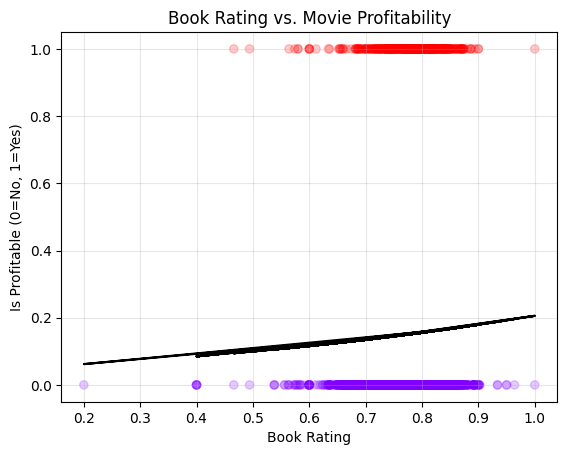

In [78]:
# Visualize the Data: Scatterplot of Logistic Regression
# Predict if movie is profitable based on book rating

x = df[['Book Rating']].dropna()
y = df['movie_profit'] > 0
y = y[x.index] # Align X and y after dropping NaN values

# Fit Logistic Regression model to draw a curve
model = LogisticRegression()
model.fit(x, y)

plt.scatter(x, y, c=y, cmap='rainbow', alpha = 0.2)

# curve reference: https://stackoverflow.com/questions/69446699/matplotlib-plot-curve-logistic-regression
plt.plot(x, model.predict_proba(x)[:,1], color="black") 

plt.grid(True, alpha=0.3)
plt.xlabel('Book Rating')
plt.ylabel('Is Profitable (0=No, 1=Yes)')
plt.title('Book Rating vs. Movie Profitability')
plt.show()

In [79]:
# Use multiple features
features = ['Book Rating', 'Movie Rating', 'movie_budget', 'imdb_total_votes', 'Pages', 'RatingDistTotal']
df_model = df[features + ['movie_profit']].dropna()
x = df_model[features]
y = df_model['movie_profit'] > 0

In [80]:
# Feature scaling
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [81]:
# Split the Dataset
# x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=1)
# Split data with stratification to keep both classes in test set
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.3, random_state=42, stratify=y
)

In [82]:
# Test on number of observations
x_train.shape 

(451, 6)

In [83]:
# Perform Logistic Regression
# log_reg = LogisticRegression()
# log_reg.fit(x_train, y_train)

# Train model with balanced data AND class weights
log_reg = LogisticRegression(
    class_weight='balanced',  # Extra insurance for balanced treatment
    max_iter=2000,
    C=0.5,  # Regularization to prevent overfitting
    random_state=42
)
log_reg.fit(x_train, y_train)

LogisticRegression(C=0.5, class_weight='balanced', max_iter=2000,
                   random_state=42)

In [84]:
# Make prediction using the model
# Using x_test to predict the corresponding value for y
y_pred = log_reg.predict(x_test) 

In [85]:
# Display the Confusion Matrix values
cm = confusion_matrix(y_test, y_pred)

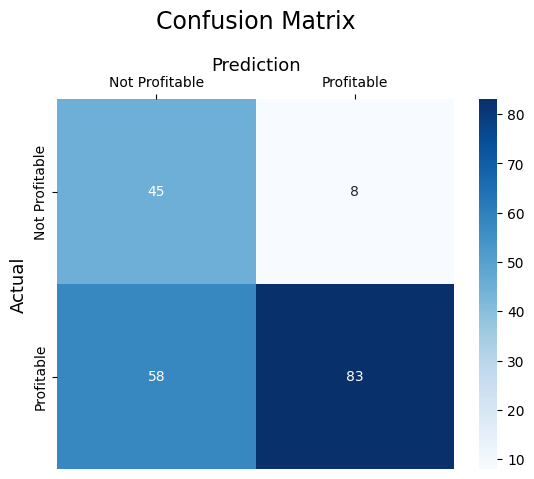

Classification Report:
                precision    recall  f1-score   support

Not Profitable       0.44      0.85      0.58        53
    Profitable       0.91      0.59      0.72       141

      accuracy                           0.66       194
     macro avg       0.67      0.72      0.65       194
  weighted avg       0.78      0.66      0.68       194



In [86]:
# Confusion Matrix Heatmap
# Reference: https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/
sns.heatmap(cm, 
            annot=True,
            fmt='g', 
            cmap = "Blues",
            xticklabels=['Not Profitable','Profitable'],
            yticklabels=['Not Profitable','Profitable'])
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()
plt.show()

# Classifications Report based on Confusion Metrics
print("Classification Report:")
print(classification_report(y_test, y_pred,
                          target_names=['Not Profitable', 'Profitable']))